In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('data/clustered_data.csv')
df.head()
df= df.drop(columns='Unnamed: 0')

In [3]:
# See the percentae of data in each cluster

df['cluster'].value_counts(normalize=True).mul(100).round(2)

cluster
2    65.45
1    20.90
0    13.65
Name: proportion, dtype: float64

In [4]:
# Designate numeric and categorical columns

numeric_cols = df.select_dtypes(include='number').columns.tolist()

categorical_cols = df.select_dtypes(include='object').columns.tolist()

In [5]:
# Numeric means per cluster
numeric_profile = df.groupby('cluster')[numeric_cols].mean().round(2)
print(numeric_profile)

           age  campaign  term_deposit_subscribed  consumer_confidence_index  \
cluster                                                                        
0        40.44      1.96                     0.26                     -41.68   
1        38.94      2.27                     0.37                     -44.22   
2        40.22      2.79                     0.00                     -39.10   

         euribor_3mo_rate  previous_contacted  last_contact_duration_sec  \
cluster                                                                    
0                    1.50                1.26                     265.55   
1                    1.83                0.00                     376.34   
2                    4.63                0.00                     219.45   

         was_previously_contacted  positive_campaign_result  cluster  
cluster                                                               
0                            0.27                       1.0      0.0  
1    

In [6]:
# Conversion rate per cluster!

conversion = df.groupby('cluster')['term_deposit_subscribed'].mean().mul(100).round(2)
print(conversion)

cluster
0    26.43
1    36.67
2     0.00
Name: term_deposit_subscribed, dtype: float64


In [7]:
# Mode of categorical columns per cluster

categorical_profile = df.groupby('cluster')[categorical_cols].agg(lambda x: x.value_counts().index[0])
print(categorical_profile)

            job has_housing_loan has_personal_loan default_status  \
cluster                                                             
0        admin.              yes                no             no   
1        admin.              yes                no             no   
2        admin.              yes                no             no   

        marital_status    education_level communication_type  \
cluster                                                        
0              married  university.degree           cellular   
1              married  university.degree           cellular   
2              married  university.degree           cellular   

        last_contact_month  
cluster                     
0                      may  
1                      may  
2                      may  


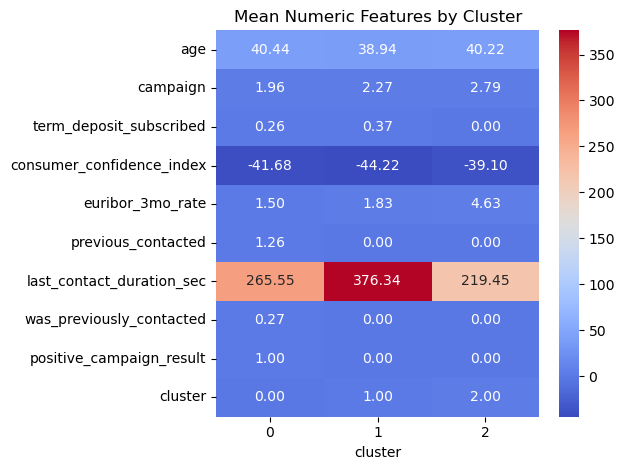

In [8]:
# Heatmap of numeric features
import seaborn as sns
import matplotlib.pyplot as plt

cluster_means = df.groupby('cluster')[numeric_cols].mean()
sns.heatmap(cluster_means.T, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Mean Numeric Features by Cluster')
plt.tight_layout()
plt.show()

In [9]:
# Subscription rates by cluster

sub_by_cluster = df.groupby('cluster')['term_deposit_subscribed'].mean().round(4)
sub_by_cluster

cluster
0    0.2643
1    0.3667
2    0.0000
Name: term_deposit_subscribed, dtype: float64

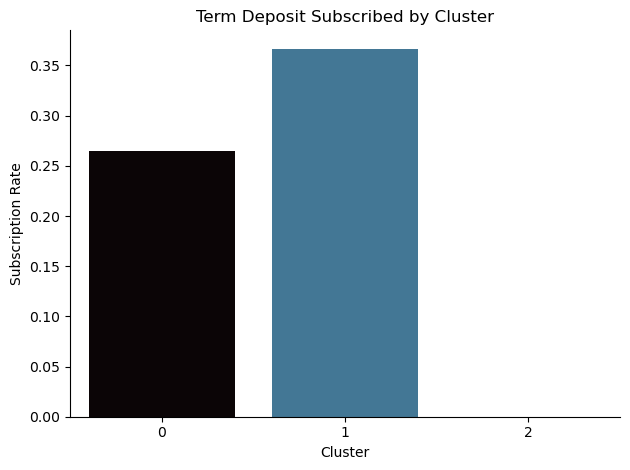

In [10]:
# Term Deposit Subscribed by cluster

sns.barplot(x=sub_by_cluster.index, y=sub_by_cluster.values, palette='mako', hue=sub_by_cluster.index, legend=False)
plt.title('Term Deposit Subscribed by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Subscription Rate')
sns.despine()
plt.tight_layout()
plt.show()

In [11]:
# Euribor 3 month rate by cluster
# This rate is a key benchmark for floating-rate loans, mortgages, and derivatives in the Eurozone, 
# reflecting the cost of interbank borrowing over a three-month period


euribor_by_cluster = df.groupby('cluster')['euribor_3mo_rate'].median()
euribor_by_cluster

cluster
0    1.266
1    1.327
2    4.957
Name: euribor_3mo_rate, dtype: float64

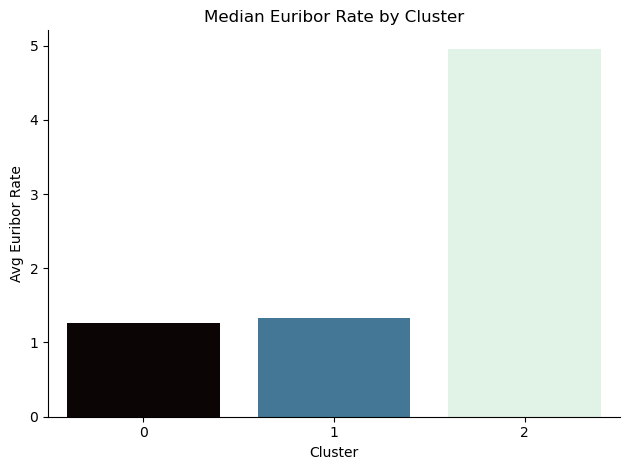

In [12]:
# Euribor Rate Subscribed by cluster

sns.barplot(x=euribor_by_cluster.index, y=euribor_by_cluster.values, palette='mako', hue=euribor_by_cluster.index, legend=False)
plt.title('Median Euribor Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Avg Euribor Rate')
plt.tight_layout()
sns.despine()
plt.show()

In [13]:
# Median seconds by cluster of last contact

contact_duaration_by_cluster = df.groupby('cluster')['last_contact_duration_sec'].median()
contact_duaration_by_cluster

cluster
0    198.0
1    248.0
2    162.0
Name: last_contact_duration_sec, dtype: float64

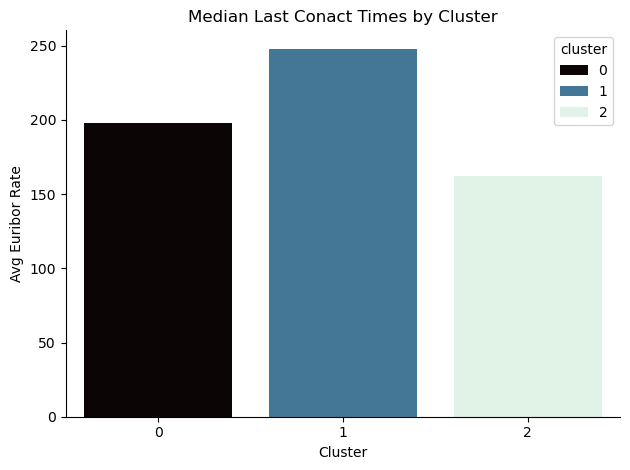

In [14]:
#  Median last contact duration by cluster

sns.barplot(x=contact_duaration_by_cluster.index, y=contact_duaration_by_cluster.values, palette='mako', hue=contact_duaration_by_cluster.index)
plt.title('Median Last Conact Times by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Avg Euribor Rate')
plt.tight_layout()
sns.despine()
plt.show()

In [15]:
# Median age by cluster

med_age_by_cluster = df.groupby('cluster')['age'].median()
med_age_by_cluster

cluster
0    37.0
1    36.0
2    39.0
Name: age, dtype: float64

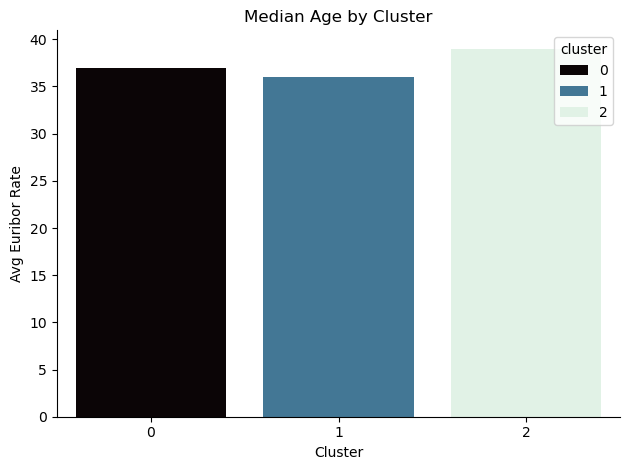

In [16]:
# Median age by cluster

sns.barplot(x=med_age_by_cluster.index, y=med_age_by_cluster.values, palette='mako', hue=med_age_by_cluster.index)
plt.title('Median Age by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Avg Euribor Rate')
plt.tight_layout()
sns.despine()
plt.show()

In [17]:
df.groupby('cluster')['default_status'].count()

cluster
0     5433
1     8320
2    26050
Name: default_status, dtype: int64

In [18]:
# Count of education type by cluster

edu_by_cluster = df.groupby(['cluster', 'education_level'])['education_level'].size().reset_index(name='count')
edu_by_cluster

,cluster,education_level,count
0,0,basic.4y,494
1,0,basic.6y,256
2,0,basic.9y,748
3,0,high.school,1448
4,0,illiterate,2
5,0,professional.course,701
6,0,university.degree,1784
7,1,basic.4y,801
8,1,basic.6y,483
9,1,basic.9y,1416


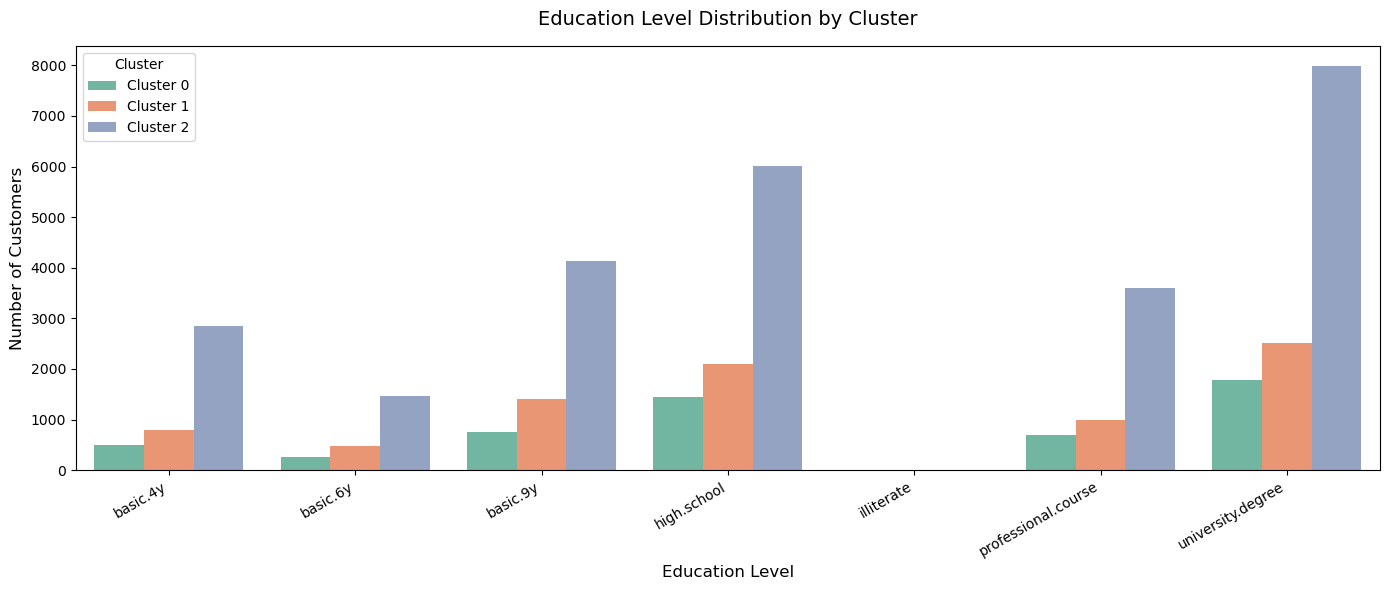

In [19]:
# Marital status by cluster

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=edu_by_cluster,
    x='education_level',    # education on x-axis
    y='count',              # bar height = count
    hue='cluster',          # grouped by cluster (0, 1, 2)
    palette='Set2',
    errorbar=None
)

ax.set_title('Education Level Distribution by Cluster', fontsize=14, pad=15)
ax.set_xlabel('Education Level', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

In [20]:
# Marital Status by Cluster

marital_by_cluster = df.groupby(['cluster', 'marital_status'])['marital_status'].size().reset_index(name='count')
marital_by_cluster

,cluster,marital_status,count
0,0,divorced,612
1,0,married,3012
2,0,single,1809
3,1,divorced,856
4,1,married,4676
5,1,single,2788
6,2,divorced,3010
7,2,married,16422
8,2,single,6618


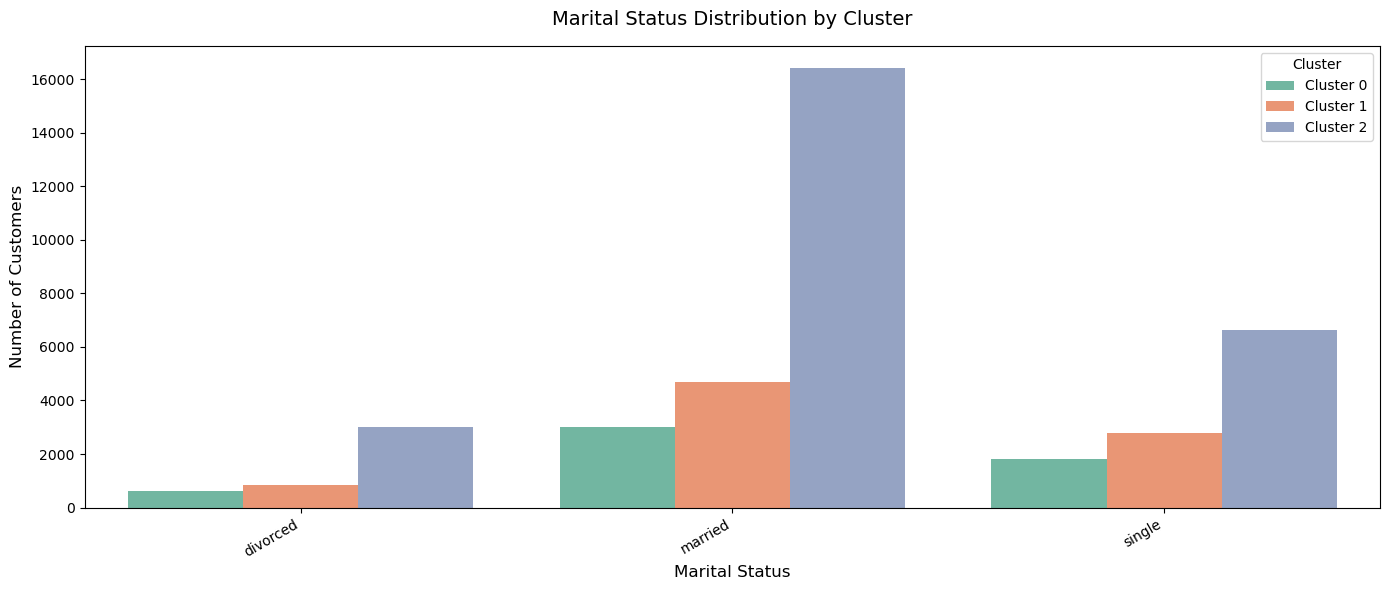

In [21]:
# Marital Status by cluster

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=marital_by_cluster,
    x='marital_status',    
    y='count',              
    hue='cluster',          
    palette='Set2',
    errorbar=None
)

ax.set_title('Marital Status Distribution by Cluster', fontsize=14, pad=15)
ax.set_xlabel('Marital Status', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

In [22]:
# Communication type by Cluster

coms_by_cluster = df.groupby(['cluster', 'communication_type'])['communication_type'].size().reset_index(name='count')
coms_by_cluster

,cluster,communication_type,count
0,0,cellular,5039
1,0,telephone,394
2,1,cellular,7143
3,1,telephone,1177
4,2,cellular,13187
5,2,telephone,12863


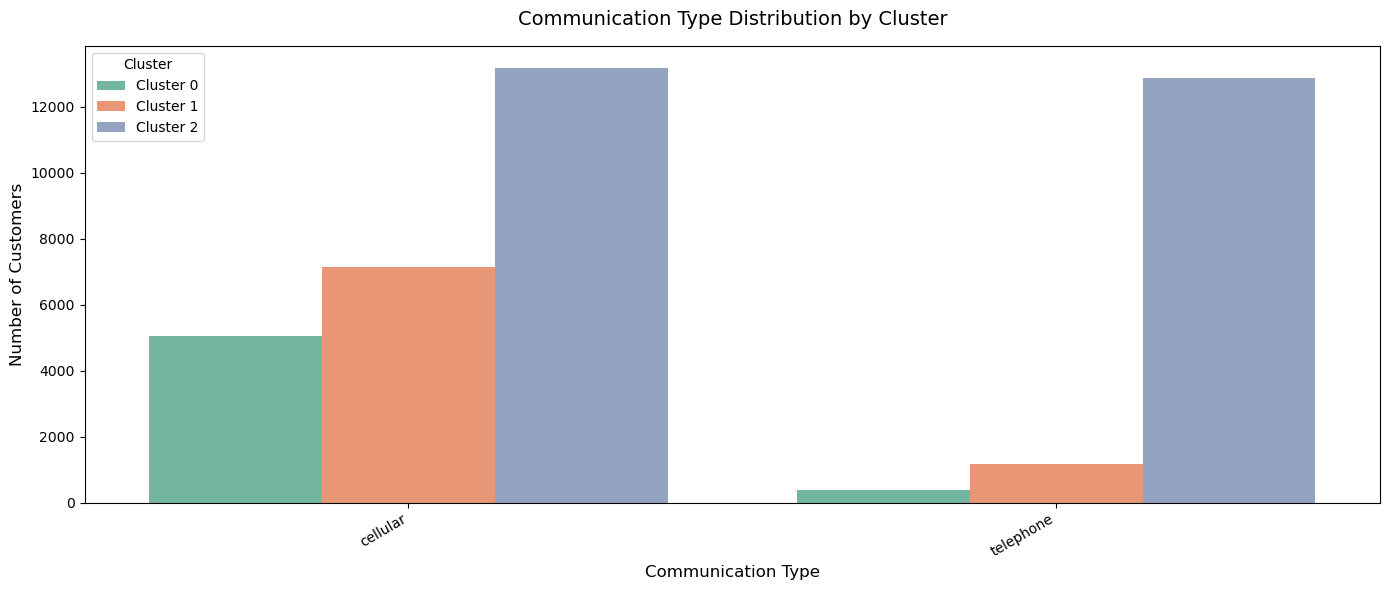

In [23]:
# Communication Type by cluster

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=coms_by_cluster,
    x='communication_type',    
    y='count',              
    hue='cluster',          
    palette='Set2',
    errorbar=None
)

ax.set_title('Communication Type Distribution by Cluster', fontsize=14, pad=15)
ax.set_xlabel('Communication Type', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

In [24]:
# Job type by Cluster

job_by_cluster = df.groupby(['cluster', 'job'])['job'].size().reset_index(name='count')
job_by_cluster

,cluster,job,count
0,0,admin.,1473
1,0,blue-collar,986
2,0,entrepreneur,173
3,0,housemaid,110
4,0,management,416
5,0,retired,378
6,0,self-employed,170
7,0,services,499
8,0,student,272
9,0,technician,804


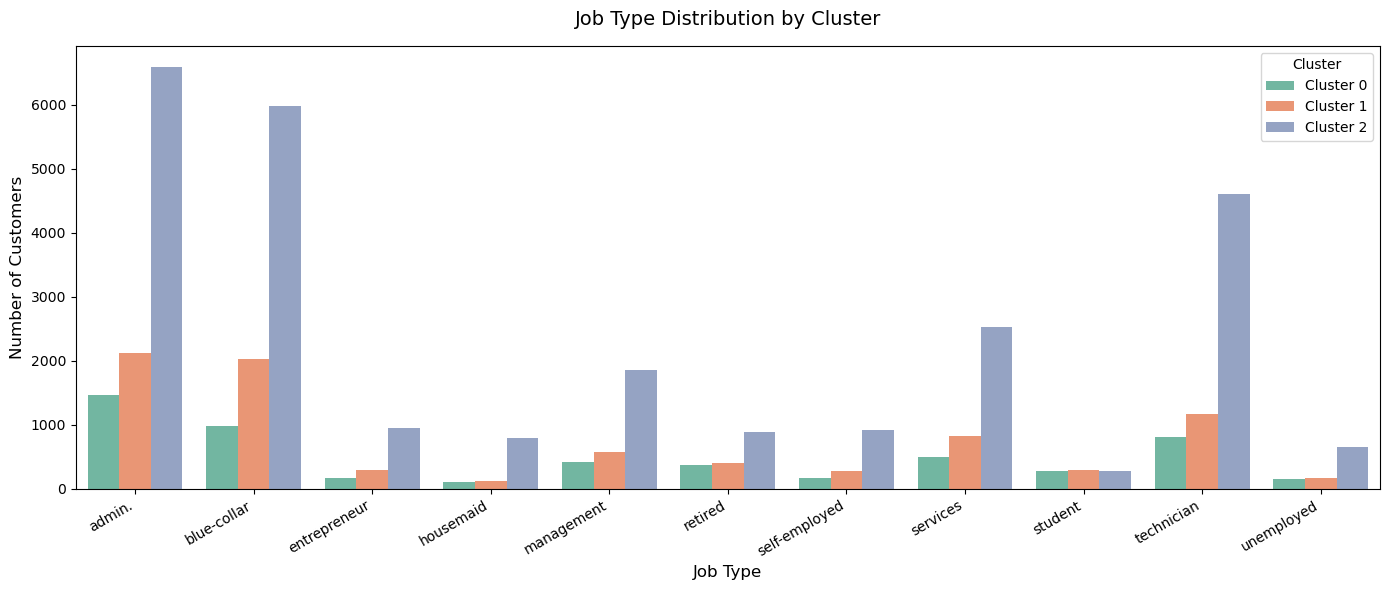

In [ ]:
# Job Type by Cluster


plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=job_by_cluster,
    x='job',    
    y='count',              
    hue='cluster',          
    palette='Set2',
    errorbar=None
)

ax.set_title('Job Type Distribution by Cluster', fontsize=14, pad=15)
ax.set_xlabel('Job Type', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

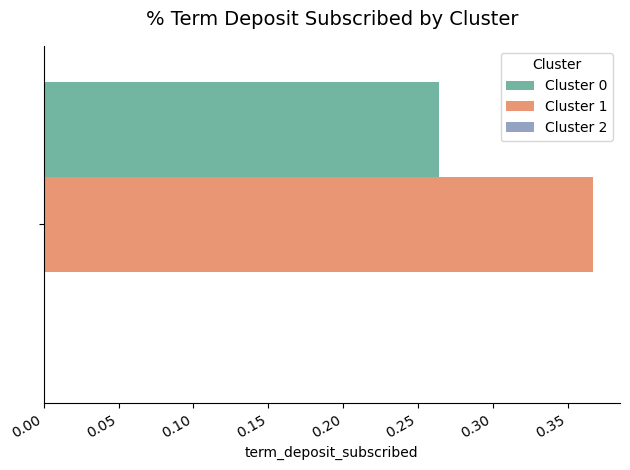

In [ ]:
# Percent make-up of subscribers by cluster

ax = sns.barplot(
    data=df,
    x='term_deposit_subscribed',                 
    hue='cluster',          
    palette='Set2',
    errorbar=None
)

ax.set_title('% Term Deposit Subscribed by Cluster', fontsize=14, pad=15)

ax.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.xticks(rotation=30, ha='right', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

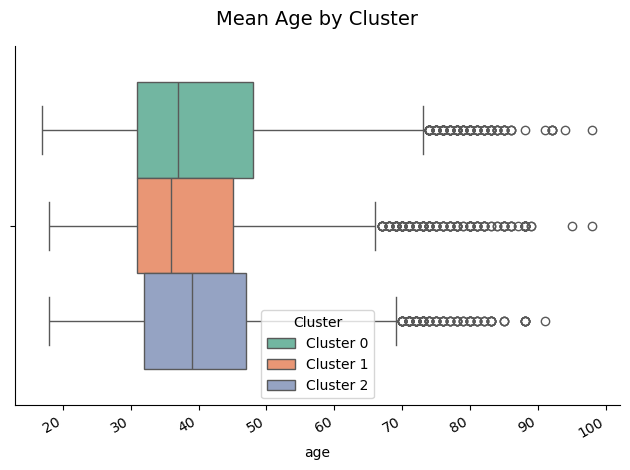

In [44]:
# Avg age by Cluster

ax = sns.boxplot(
    data=df,
    x='age',                 
    hue='cluster',          
    palette='Set2'
)

ax.set_title('Mean Age by Cluster', fontsize=14, pad=15)

ax.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.xticks(rotation=30, ha='right', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

In [45]:
df.columns

Index(['age', 'job', 'campaign', 'term_deposit_subscribed', 'has_housing_loan',
       'has_personal_loan', 'default_status', 'consumer_confidence_index',
       'euribor_3mo_rate', 'marital_status', 'education_level',
       'previous_contacted', 'communication_type', 'last_contact_month',
       'last_contact_duration_sec', 'was_previously_contacted',
       'positive_campaign_result', 'cluster'],
      dtype='object')

In [72]:
# Housing Loans by Cluster

housing_by_clust = df.groupby(['cluster', 'has_housing_loan'])['has_housing_loan'].size().reset_index(name='count')
housing_by_clust

,cluster,has_housing_loan,count
0,0,no,2344
1,0,yes,3089
2,1,no,3522
3,1,yes,4798
4,2,no,12561
5,2,yes,13489


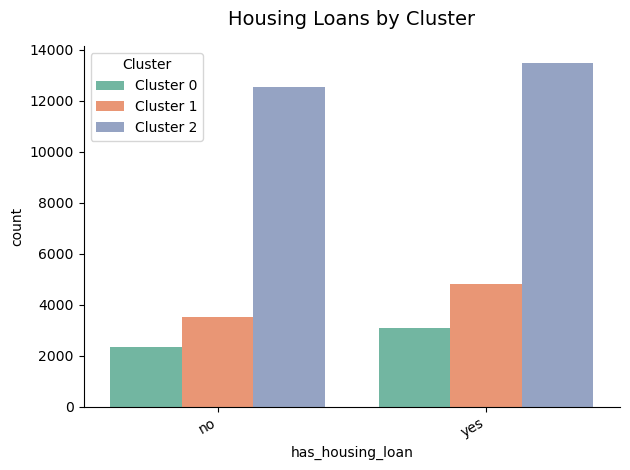

In [73]:
# Housing Loans by Cluster

ax = sns.barplot(
    data=housing_by_clust,
    x='has_housing_loan', 
    y='count',
    hue='cluster',                          
    palette='Set2',
    errorbar=None
)

ax.set_title('Housing Loans by Cluster', fontsize=14, pad=15)

ax.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.xticks(rotation=30, ha='right', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

In [75]:
# Personal Loans by Cluster

personal_by_clust = df.groupby(['cluster', 'has_personal_loan'])['has_personal_loan'].size().reset_index(name='count')
personal_by_clust

,cluster,has_personal_loan,count
0,0,no,4592
1,0,yes,841
2,1,no,7009
3,1,yes,1311
4,2,no,22019
5,2,yes,4031


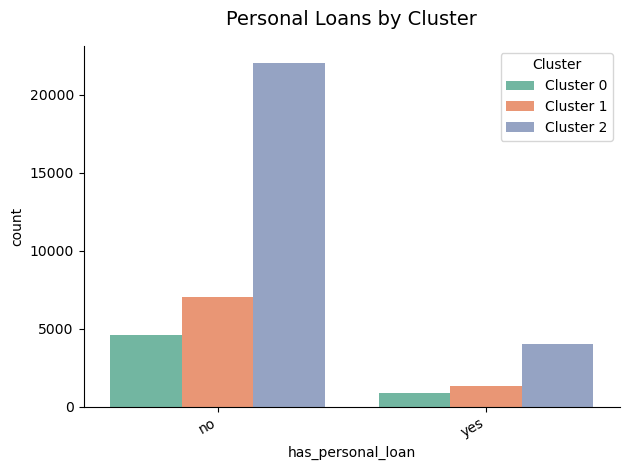

In [76]:
# Personal Loans by Cluster

ax = sns.barplot(
    data=personal_by_clust,
    x='has_personal_loan', 
    y='count',
    hue='cluster',                          
    palette='Set2',
    errorbar=None
)

ax.set_title('Personal Loans by Cluster', fontsize=14, pad=15)

ax.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.xticks(rotation=30, ha='right', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

In [77]:
# Personal Loans by Cluster

default_by_clust = df.groupby(['cluster', 'default_status'])['default_status'].size().reset_index(name='count')
default_by_clust

,cluster,default_status,count
0,0,no,4877
1,0,unknown,555
2,0,yes,1
3,1,no,7146
4,1,unknown,1174
5,2,no,19564
6,2,unknown,6484
7,2,yes,2


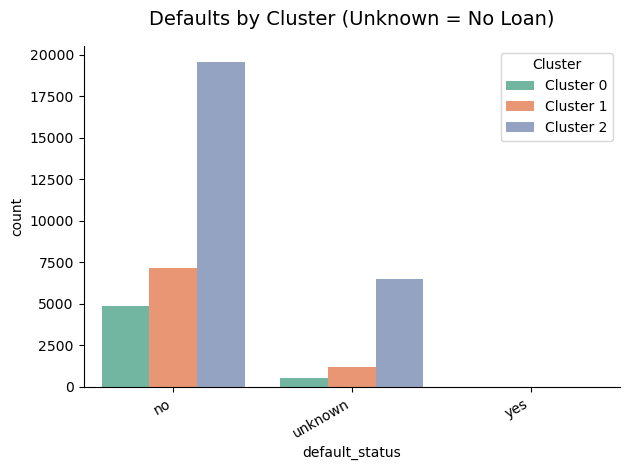

In [79]:
# Defaults by Cluster

ax = sns.barplot(
    data=default_by_clust,
    x='default_status', 
    y='count',
    hue='cluster',                          
    palette='Set2',
    errorbar=None
)

ax.set_title('Defaults by Cluster (Unknown = No Loan)', fontsize=14, pad=15)

ax.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.xticks(rotation=30, ha='right', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

In [84]:
# Housing Loans by Cluster

euribor_by_clust = df.groupby(['cluster'])['euribor_3mo_rate'].mean().reset_index(name='mean_rate')
euribor_by_clust

,cluster,mean_rate
0,0,1.497428
1,1,1.830136
2,2,4.632504


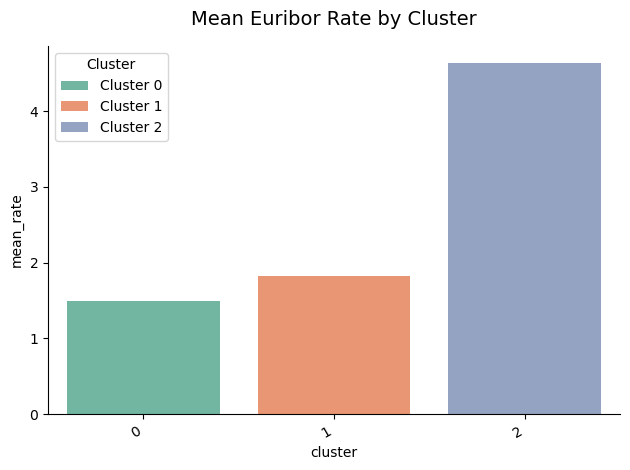

In [86]:
# Mean Euribor rate by Cluster

ax = sns.barplot(
    data=euribor_by_clust,
    x='cluster', 
    y='mean_rate',
    hue='cluster',                          
    palette='Set2',
    errorbar=None
)

ax.set_title('Mean Euribor Rate by Cluster', fontsize=14, pad=15)

ax.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.xticks(rotation=30, ha='right', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()